In [1]:
import geopandas as gpd
import os
import numpy as np
import itertools
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
os.chdir("..")

# Effects of Heat

In [3]:
gdf_population = gpd.read_parquet("data/evaluation/evaluation_raster_population.parquet")

In [4]:
gdf_results = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")

In [5]:
average_time_columns = [col for col in gdf_results.columns if col.startswith("average_time")]

In [6]:
gdf_results_average_time = gdf_results.copy()

for col in average_time_columns:
    gdf_results_average_time[col] = gdf_results_average_time[col].apply(lambda x: np.average(list(x.values())))

In [7]:
for tp in ["walk", "bike", "walk_PT"]:
    for vuln in [1,2,3,4,5]:
        relevant_columns = [f"average_time_{tp}_{dt}_vuln{vuln}_{n}" for dt, n in itertools.product(["morning","noon", "afternoon", "evening"], [1,2])]
        gdf_results_average_time[f"average_time_{tp}_vuln{vuln}"] = gdf_results_average_time[relevant_columns].mean(axis=1)
    gdf_results_average_time[f"average_time_{tp}"] = (gdf_results_average_time[f"average_time_{tp}_1"] + gdf_results_average_time[f"average_time_{tp}_2"] + gdf_results_average_time[f"average_time_{tp}_20"]) / 3




/home/lukas/data-preprocessing/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/lukas/data-preprocessing/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/home/lukas/data-preprocessing/.venv/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

In [8]:
gdf_results_average_time = gdf_results_average_time.drop(columns=average_time_columns)

In [9]:
gdf_results_average_time["population"] = gdf_population["value_result"]
gdf_results_average_time["population"] = gdf_results_average_time["population"].fillna(0)

In [10]:
results = {}

for tp in ["walk", "bike", "walk_PT"]:
    results[f"average_time_{tp}"] = {
        "average": np.average(gdf_results_average_time[f"average_time_{tp}"], weights=gdf_results_average_time["population"]),
        "std": np.sqrt(np.cov(gdf_results_average_time[f"average_time_{tp}"], aweights=gdf_results_average_time["population"]))
    }
    for vuln in [1,2,3,4,5]:
        results[f"average_time_{tp}_vuln{vuln}"] = {
            "average": np.average(gdf_results_average_time[f"average_time_{tp}_vuln{vuln}"], weights=gdf_results_average_time["population"]),
            "std": np.sqrt(np.cov(gdf_results_average_time[f"average_time_{tp}_vuln{vuln}"], aweights=gdf_results_average_time["population"]))
        }
    

In [11]:
gdf_weighted = pd.DataFrame(results)

In [12]:
gdf_weighted

,average_time_walk,average_time_walk_vuln1,average_time_walk_vuln2,average_time_walk_vuln3,average_time_walk_vuln4,average_time_walk_vuln5,average_time_bike,average_time_bike_vuln1,average_time_bike_vuln2,average_time_bike_vuln3,average_time_bike_vuln4,average_time_bike_vuln5,average_time_walk_PT,average_time_walk_PT_vuln1,average_time_walk_PT_vuln2,average_time_walk_PT_vuln3,average_time_walk_PT_vuln4,average_time_walk_PT_vuln5
average,6.793690,8.533819,12.001557,15.415552,18.796091,22.157025,1.589778,1.998781,2.813802,3.616229,4.409639,5.197916,6.011397,7.749502,10.757309,13.701527,16.612639,19.499331
std,5.648443,8.584367,12.240839,15.941763,19.654238,23.373040,1.284689,1.943879,2.772037,3.610465,4.451800,5.295630,4.441642,6.485409,8.846818,11.243772,13.658203,16.079347


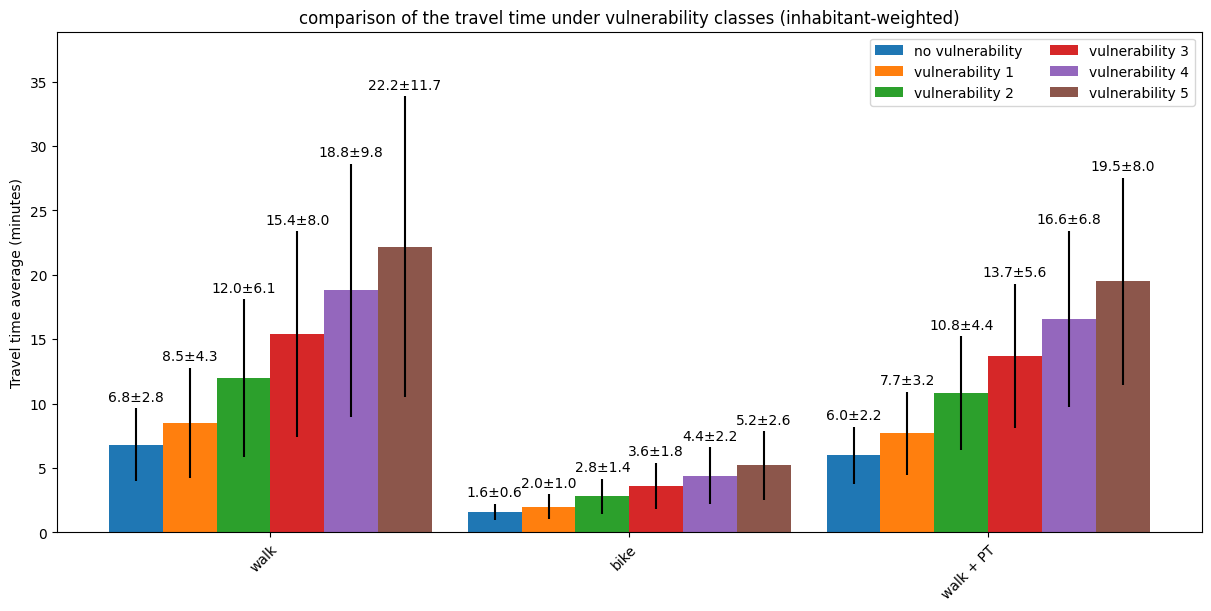

In [13]:
# n_s = {
#     "walk" : gdf_weighted[["average_time_walk"] + [f"average_time_walk_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["average"],
#     "bike": gdf_weighted[["average_time_bike"] + [f"average_time_bike_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["average"],
#     "walk_PT": gdf_weighted[["average_time_walk_PT"] + [f"average_time_walk_PT_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["average"]
# }

# standard_deviations = {
#     "walk" : gdf_weighted[["average_time_walk"] + [f"average_time_walk_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["std"],
#     "bike": gdf_weighted[["average_time_bike"] + [f"average_time_bike_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["std"],
#     "walk_PT": gdf_weighted[["average_time_walk_PT"] + [f"average_time_walk_PT_vuln{vuln}" for vuln in [1,2,3,4,5]]].loc["std"]
# }

n_s = {
    "no vulnerability": gdf_weighted[[f"average_time_{tp}" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
    "vulnerability 1": gdf_weighted[[f"average_time_{tp}_vuln1" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
    "vulnerability 2": gdf_weighted[[f"average_time_{tp}_vuln2" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
    "vulnerability 3": gdf_weighted[[f"average_time_{tp}_vuln3" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
    "vulnerability 4": gdf_weighted[[f"average_time_{tp}_vuln4" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
    "vulnerability 5": gdf_weighted[[f"average_time_{tp}_vuln5" for tp in ["walk", "bike", "walk_PT"]]].loc["average"],
}

standard_deviations = {
    "no vulnerability": gdf_weighted[[f"average_time_{tp}" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
    "vulnerability 1": gdf_weighted[[f"average_time_{tp}_vuln1" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
    "vulnerability 2": gdf_weighted[[f"average_time_{tp}_vuln2" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
    "vulnerability 3": gdf_weighted[[f"average_time_{tp}_vuln3" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
    "vulnerability 4": gdf_weighted[[f"average_time_{tp}_vuln4" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
    "vulnerability 5": gdf_weighted[[f"average_time_{tp}_vuln5" for tp in ["walk", "bike", "walk_PT"]]].loc["std"],
}

x = np.arange(len(n_s["no vulnerability"])) * 2  # the label locations, spaced to fit wider bars
width = 0.3  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(12, 6))

max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement, 1)
    y_errs = np.array(standard_deviations.get(attribute)) / 2

    max_value = max(max_value, max(measurement) + max(y_errs))
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, yerr=y_errs)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}±{err:.1f}" for val, err in zip(measurement, y_errs)],
        padding=3,
    )
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel("Travel time average (minutes)")
ax.set_title("comparison of the travel time under vulnerability classes (inhabitant-weighted)")
ax.set_xticks(
    x + width * 2.5,
    ["walk", "bike", "walk + PT"],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)
ax.legend(loc="upper right", ncols=2)
ax.set_ylim(0, max_value + 5)

plt.show()